# E4 — Real-calibration learning curve

Goal: quantify how much real-Jamming supervision a synthetic-anomaly + normal
training mix needs before the binary detector recovers usable detection on the
held-out **real** Jamming windows. The primary protocol uses
``make_fullscale_split`` (the regime in which the paper observes near-zero
detection at scale, recovered with ~10% real). Two outputs accompany the
learning curve:

1. A learning-curve summary across fractions ``f ∈ {0, 0.01, 0.02, 0.05, 0.10,
   0.25, 0.50, 1.00}`` of the **train-eligible real Jamming pool** with 10 seeds
   per fraction.
2. Four control conditions (extra synthetic, extra normal, sample-weight reweighting,
   RSRP-matched synthetic) evaluated at the headline ``f = 0.10`` budget.

The notebook never trains on test windows and never reuses any test sample as
validation. All randomness flows through explicit ``random_state`` / ``seed``.


## 0. Bootstrap

In [1]:
# Bootstrap: make _shared importable, set plot defaults, suppress noisy warnings.
from pathlib import Path
import sys
sys.path.insert(0, str(Path('..').resolve()))

from _shared.notebook_helpers import setup_paths, configure_matplotlib
EXPERIMENTS_ROOT = setup_paths()
configure_matplotlib()

import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

from _shared.data_utils import (
    KPI_NAMES,
    REAL_ANOMALY_TYPES,
    feature_names,
    get_or_build_corpus_features,
    load_corpus,
    make_fullscale_split,
)

HERE = Path('.').resolve()
RESULTS = HERE / 'results'
FIGURES = HERE / 'figures'
RESULTS.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)
print('Working dir :', HERE)
print('Results dir :', RESULTS)
print('Figures dir :', FIGURES)


Working dir : experiments/E4_real_calibration_learning_curve
Results dir : experiments/E4_real_calibration_learning_curve/results
Figures dir : experiments/E4_real_calibration_learning_curve/figures


In [2]:
corpus = load_corpus(verbose=True)
F_full, feat_names = get_or_build_corpus_features(verbose=True)
F_full = np.asarray(F_full, dtype=np.float32)
assert F_full.shape[0] == corpus.n
assert len(feat_names) == F_full.shape[1]
print('Corpus size       :', corpus.n)
print('Feature matrix    :', F_full.shape)
print('First 4 features  :', feat_names[:4])


[data_utils] Loading cached corpus from experiments/_shared/cache/telecomts_corpus_v1.pkl
[data_utils] Loading cached corpus features from experiments/_shared/cache/telecomts_kpi_summary_features_v1.npz
Corpus size       : 32000
Feature matrix    : (32000, 240)
First 4 features  : [np.str_('RSRP__mean'), np.str_('RSRP__std'), np.str_('RSRP__min'), np.str_('RSRP__max')]


## 1. Setup — fullscale split, train pools, validation carve-out

We use ``make_fullscale_split(corpus, seed=42)`` (~25,600 train / 6,400 test
with the natural anomaly rate). The val set is carved deterministically from
the train partition with a stratified 10% split (``random_state=0``); the
**train-eligible real Jamming pool** is then defined on the post-val remainder
to guarantee val/train disjointness.


In [3]:
split = make_fullscale_split(corpus, seed=42)
train_idx_all = np.asarray(split['train'])
test_idx = np.asarray(split['test'])
print('train (raw) size :', train_idx_all.size)
print('test       size :', test_idx.size)

y_train_all = corpus.y[train_idx_all]
# Stratified val carve-out, with a non-stratified fallback if any class has too
# few samples (guards subsample/edge-case runs where a class might collapse).
try:
    train_remaining_pos, val_pos = train_test_split(
        np.arange(train_idx_all.size),
        test_size=0.10,
        stratify=y_train_all,
        random_state=0,
    )
except ValueError as e:
    print('[E4] stratified split failed (', e, '); falling back to stratify=None')
    train_remaining_pos, val_pos = train_test_split(
        np.arange(train_idx_all.size),
        test_size=0.10,
        stratify=None,
        random_state=0,
    )
train_remaining = train_idx_all[train_remaining_pos]
val_idx = train_idx_all[val_pos]

# Sanity: zero overlap between val and train_remaining and test.
assert np.intersect1d(train_remaining, val_idx).size == 0
assert np.intersect1d(train_remaining, test_idx).size == 0
assert np.intersect1d(val_idx, test_idx).size == 0
print('train_remaining  :', train_remaining.size)
print('val              :', val_idx.size)
print('test             :', test_idx.size)


train (raw) size : 25600
test       size : 6400
train_remaining  : 23040
val              : 2560
test             : 6400


In [4]:
# Pools defined on train_remaining (post-val) so val never bleeds into training.
y_remain = corpus.y[train_remaining]
origin_remain = corpus.anomaly_origin[train_remaining]

train_norm = train_remaining[y_remain == 0]
train_real_pool = train_remaining[origin_remain == 'real']
train_synth_pool = train_remaining[origin_remain == 'synthetic']

# Test partitions: real Jamming and synthetic test groups.
y_test = corpus.y[test_idx]
origin_test = corpus.anomaly_origin[test_idx]
type_test = corpus.anomaly_type[test_idx]
test_norm_mask = (y_test == 0)
test_real_mask = (origin_test == 'real')
test_syn_mask = (origin_test == 'synthetic')
n_test_real = int(test_real_mask.sum())
n_test_syn = int(test_syn_mask.sum())

pool_summary = {
    'split': 'fullscale (seed=42)',
    'train_norm': int(train_norm.size),
    'train_real_pool': int(train_real_pool.size),
    'train_synth_pool': int(train_synth_pool.size),
    'val': int(val_idx.size),
    'val_normal': int((corpus.y[val_idx] == 0).sum()),
    'val_anomaly': int((corpus.y[val_idx] == 1).sum()),
    'test': int(test_idx.size),
    'test_normal': int(test_norm_mask.sum()),
    'test_real_jamming': n_test_real,
    'test_synthetic_anomaly': n_test_syn,
}
for k, v in pool_summary.items():
    print(f'{k:>22s} : {v}')

with (RESULTS / 'E4_pool_summary.json').open('w') as f:
    json.dump(pool_summary, f, indent=2)
print('\nWrote', RESULTS / 'E4_pool_summary.json')


                 split : fullscale (seed=42)
            train_norm : 22151
       train_real_pool : 185
      train_synth_pool : 704
                   val : 2560
            val_normal : 2461
           val_anomaly : 99
                  test : 6400
           test_normal : 6153
     test_real_jamming : 69
test_synthetic_anomaly : 178

Wrote experiments/E4_real_calibration_learning_curve/results/E4_pool_summary.json


## 2. Primary model and evaluation helper

Detector: ``HistGradientBoostingClassifier`` on the 240-dim engineered KPI
summary features (``F_full``). Threshold is chosen on the validation set to
maximise F1, then applied to the held-out test set. Group masks identify the
normal, real-Jamming, and synthetic-anomaly subsets of the test partition.


In [5]:
def _positive_proba(clf, X):
    """Return positive-class probabilities, robust to single-class HGB fits.

    HGB always emits a 2-column predict_proba in current sklearn versions, but
    if it ever falls back to a single column (training set with no positives),
    return zeros instead of crashing on ``[:, 1]``.
    """
    proba = clf.predict_proba(X)
    if proba.ndim == 2 and proba.shape[1] >= 2:
        # Locate the positive (1) column; HGB orders columns by clf.classes_.
        classes = list(getattr(clf, 'classes_', [0, 1]))
        if 1 in classes:
            return proba[:, classes.index(1)]
        return proba[:, -1]
    return np.zeros(proba.shape[0], dtype=float)


def _fit_score_threshold(train_idx, val_idx, sample_weight=None, seed=0):
    """Fit HGB on (train_idx) and pick the threshold that maximises val F1.

    Returns: (clf, threshold, val_scores).
    """
    F_tr = F_full[train_idx]
    y_tr = corpus.y[train_idx]
    clf = HistGradientBoostingClassifier(random_state=seed)
    if sample_weight is not None:
        clf.fit(F_tr, y_tr, sample_weight=np.asarray(sample_weight, dtype=float))
    else:
        clf.fit(F_tr, y_tr)
    val_scores = _positive_proba(clf, F_full[val_idx])
    y_val = corpus.y[val_idx]
    train_has_both_classes = (np.unique(y_tr).size >= 2)
    if (not train_has_both_classes) or y_val.sum() == 0 or y_val.sum() == y_val.size:
        threshold = 0.5
    else:
        prec, rec, thr = precision_recall_curve(y_val, val_scores)
        # precision_recall_curve returns prec/rec of len n+1 and thr of len n.
        # Drop the trailing (rec=0, prec=1) sentinel so f1 aligns with thr.
        prec_a, rec_a = prec[:-1], rec[:-1]
        denom = prec_a + rec_a
        f1s = np.where(denom > 0, 2 * prec_a * rec_a / np.maximum(denom, 1e-12), 0.0)
        if f1s.size == 0:
            threshold = 0.5
        else:
            best = int(np.argmax(f1s))
            threshold = float(thr[best])
    return clf, threshold, val_scores


def evaluate(clf, threshold, test_idx, masks):
    """Compute the metric panel on the held-out test partition."""
    test_scores = _positive_proba(clf, F_full[test_idx])
    y_test = corpus.y[test_idx]
    pred = (test_scores >= threshold).astype(int)
    p = float(precision_score(y_test, pred, zero_division=0))
    r = float(recall_score(y_test, pred, zero_division=0))
    f1 = float(f1_score(y_test, pred, zero_division=0))
    if 0 < y_test.sum() < y_test.size:
        auroc = float(roc_auc_score(y_test, test_scores))
        avg_prec = float(average_precision_score(y_test, test_scores))
    else:
        auroc = float('nan')
        avg_prec = float('nan')
    norm_mask = masks['normals']
    real_mask = masks['real']
    syn_mask = masks['synthetic']
    fpr_norm = float((test_scores[norm_mask] >= threshold).mean()) if norm_mask.any() else float('nan')
    real_det = float((test_scores[real_mask] >= threshold).mean()) if real_mask.any() else float('nan')
    syn_det = float((test_scores[syn_mask] >= threshold).mean()) if syn_mask.any() else float('nan')
    real_score = float(test_scores[real_mask].mean()) if real_mask.any() else float('nan')
    syn_score = float(test_scores[syn_mask].mean()) if syn_mask.any() else float('nan')
    return {
        'precision': p,
        'recall': r,
        'f1': f1,
        'auroc': auroc,
        'avg_precision': avg_prec,
        'normal_fpr': fpr_norm,
        'real_jamming_detection_rate': real_det,
        'synthetic_detection_rate': syn_det,
        'mean_jamming_score': real_score,
        'mean_synthetic_score': syn_score,
        'threshold': float(threshold),
    }


TEST_GROUP_MASKS = {
    'normals': test_norm_mask,
    'real': test_real_mask,
    'synthetic': test_syn_mask,
}
print('Test group sizes  :',
      'normals=', int(test_norm_mask.sum()),
      'real=', int(test_real_mask.sum()),
      'synthetic=', int(test_syn_mask.sum()))


Test group sizes  : normals= 6153 real= 69 synthetic= 178


## 3. Primary learning curve

For each fraction ``f`` we sub-sample ``round(f * len(train_real_pool))`` real
Jamming windows from the **train-eligible real Jamming pool** (``f = 0`` adds
none), assemble the training set as ``train_norm ∪ train_synth_pool ∪
real_subset``, refit HGB with ``random_state=seed``, threshold-select on val,
and evaluate on test. Per-seed results are kept in
``results/E4_real_calibration_learning_curve_per_seed.csv``; the across-seed
``mean ± std`` summary is written to
``results/E4_real_calibration_learning_curve_summary.csv``.


In [6]:
from _shared.data_utils import default_seeds
FRACTIONS = [0.0, 0.01, 0.02, 0.05, 0.10, 0.25, 0.50, 1.00]
SEEDS = list(range(default_seeds(10)))  # paper uses 10; smoke shrinks via env

real_pool_size = int(train_real_pool.size)
fraction_counts = {f: max(0, int(round(f * real_pool_size))) for f in FRACTIONS}
print('Train-eligible real Jamming pool size:', real_pool_size)
for f, n_added in fraction_counts.items():
    print(f'  fraction={f:>5.2f}  added={n_added:>4d} real Jamming windows')


Train-eligible real Jamming pool size: 185
  fraction= 0.00  added=   0 real Jamming windows
  fraction= 0.01  added=   2 real Jamming windows
  fraction= 0.02  added=   4 real Jamming windows
  fraction= 0.05  added=   9 real Jamming windows
  fraction= 0.10  added=  18 real Jamming windows
  fraction= 0.25  added=  46 real Jamming windows
  fraction= 0.50  added=  92 real Jamming windows
  fraction= 1.00  added= 185 real Jamming windows


In [7]:
per_seed_rows = []
t0 = time.time()
for f in FRACTIONS:
    n_target = fraction_counts[f]
    for seed in SEEDS:
        rng = np.random.default_rng(seed)
        if n_target == 0 or real_pool_size == 0:
            real_subset = np.empty(0, dtype=train_real_pool.dtype)
            n_added = 0
        else:
            n_added = min(n_target, real_pool_size)
            real_subset = rng.choice(train_real_pool, size=n_added, replace=False)
        train_idx = np.concatenate([train_norm, train_synth_pool, real_subset])
        clf, thr, _ = _fit_score_threshold(train_idx, val_idx, seed=seed)
        metrics = evaluate(clf, thr, test_idx, TEST_GROUP_MASKS)
        row = {
            'fraction': float(f),
            'seed': int(seed),
            'n_added_real_jamming': int(n_added),
            'train_real_pool_size': real_pool_size,
            'train_set_size': int(train_idx.size),
            **metrics,
        }
        per_seed_rows.append(row)
        print(f'f={f:>5.2f} seed={seed} added={n_added:>4d} '
              f'real_det={metrics["real_jamming_detection_rate"]:.3f} '
              f'syn_det={metrics["synthetic_detection_rate"]:.3f} '
              f'F1={metrics["f1"]:.3f}')

per_seed_df = pd.DataFrame(per_seed_rows)
per_seed_df.to_csv(RESULTS / 'E4_real_calibration_learning_curve_per_seed.csv', index=False)
print(f'\nElapsed: {time.time() - t0:.1f}s')
print('Wrote', RESULTS / 'E4_real_calibration_learning_curve_per_seed.csv')


f= 0.00 seed=0 added=   0 real_det=0.000 syn_det=0.949 F1=0.799
f= 0.00 seed=1 added=   0 real_det=0.000 syn_det=0.955 F1=0.811
f= 0.00 seed=2 added=   0 real_det=0.000 syn_det=0.978 F1=0.823
f= 0.00 seed=3 added=   0 real_det=0.000 syn_det=0.927 F1=0.801
f= 0.00 seed=4 added=   0 real_det=0.000 syn_det=0.972 F1=0.822
f= 0.00 seed=5 added=   0 real_det=0.000 syn_det=0.944 F1=0.810
f= 0.00 seed=6 added=   0 real_det=0.000 syn_det=0.961 F1=0.803
f= 0.00 seed=7 added=   0 real_det=0.014 syn_det=0.978 F1=0.801
f= 0.00 seed=8 added=   0 real_det=0.000 syn_det=0.961 F1=0.818
f= 0.00 seed=9 added=   0 real_det=0.000 syn_det=0.949 F1=0.811
f= 0.01 seed=0 added=   2 real_det=0.638 syn_det=0.972 F1=0.897
f= 0.01 seed=1 added=   2 real_det=0.029 syn_det=0.949 F1=0.814
f= 0.01 seed=2 added=   2 real_det=0.507 syn_det=0.978 F1=0.893
f= 0.01 seed=3 added=   2 real_det=0.101 syn_det=0.978 F1=0.819
f= 0.01 seed=4 added=   2 real_det=0.174 syn_det=0.972 F1=0.833
f= 0.01 seed=5 added=   2 real_det=0.522

In [8]:
metric_cols = [
    'precision', 'recall', 'f1', 'auroc', 'avg_precision',
    'normal_fpr', 'real_jamming_detection_rate', 'synthetic_detection_rate',
    'mean_jamming_score', 'mean_synthetic_score', 'threshold',
]
agg = per_seed_df.groupby('fraction')[metric_cols].agg(['mean', 'std'])
agg.columns = [f'{m}_{s}' for m, s in agg.columns]
agg = agg.reset_index()
agg['n_added_real_jamming_mean'] = (
    per_seed_df.groupby('fraction')['n_added_real_jamming'].mean().values
)
agg['train_real_pool_size'] = real_pool_size
agg.to_csv(RESULTS / 'E4_real_calibration_learning_curve_summary.csv', index=False)
print('Wrote', RESULTS / 'E4_real_calibration_learning_curve_summary.csv')
agg


Wrote experiments/E4_real_calibration_learning_curve/results/E4_real_calibration_learning_curve_summary.csv


,fraction,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,auroc_mean,auroc_std,avg_precision_mean,...,synthetic_detection_rate_mean,synthetic_detection_rate_std,mean_jamming_score_mean,mean_jamming_score_std,mean_synthetic_score_mean,mean_synthetic_score_std,threshold_mean,threshold_std,n_added_real_jamming_mean,train_real_pool_size
0,0.00,0.980197,0.026294,0.690283,0.012108,0.809813,0.008859,0.882145,0.008757,0.759147,...,0.957303,0.015934,0.000368,0.000165,0.911379,0.004795,0.058690,0.071803,0.0,185
1,0.01,0.929460,0.046830,0.773684,0.067353,0.841524,0.031486,0.978752,0.028236,0.885628,...,0.970787,0.008703,0.013316,0.012078,0.910843,0.006202,0.013899,0.013464,2.0,185
2,0.02,0.938614,0.031077,0.803239,0.063103,0.864264,0.039041,0.992994,0.003480,0.927402,...,0.974157,0.004737,0.024131,0.036791,0.913648,0.007840,0.010771,0.008518,4.0,185
3,0.05,0.963915,0.021847,0.921457,0.017408,0.941881,0.006595,0.997545,0.001204,0.977677,...,0.971348,0.004919,0.147213,0.057519,0.913741,0.008328,0.021589,0.014543,9.0,185
4,0.10,0.974421,0.012932,0.966802,0.007090,0.970561,0.008352,0.998420,0.000772,0.988926,...,0.971910,0.005297,0.487265,0.072987,0.914313,0.006950,0.022671,0.015629,18.0,185
5,0.25,0.984603,0.010927,0.972874,0.011459,0.978615,0.005563,0.997591,0.001834,0.989347,...,0.965730,0.008961,0.940135,0.026950,0.914972,0.007094,0.038968,0.036139,46.0,185
6,0.50,0.985391,0.008899,0.976518,0.005975,0.980896,0.003925,0.997875,0.001601,0.989735,...,0.967978,0.007967,0.971245,0.011450,0.918360,0.009090,0.030811,0.029454,92.0,185
7,1.00,0.992606,0.005004,0.974899,0.006272,0.983657,0.003863,0.998178,0.001072,0.989855,...,0.965169,0.008703,0.987377,0.007051,0.917808,0.005014,0.042873,0.026917,185.0,185


## 4. Controls at the headline budget (f = 0.10)

We hold the additive budget fixed at ``n_added = round(0.10 *
len(train_real_pool))`` and vary **what** is added to the synthetic-only
baseline (``train_norm ∪ train_synth_pool``):

* **A. Extra synthetic** — sample ``n_added`` more synthetic anomaly windows
  from ``train_synth_pool`` (with replacement if the pool is exhausted) and
  append them to the training set.
* **B. Extra normal** — sample ``n_added`` extra normal windows from
  ``train_norm`` and append them.
* **C. Reweight synthetic** — keep the synthetic-only training set but pass
  ``sample_weight`` so the effective positive count matches the calibration
  budget (i.e. each synthetic anomaly weight is scaled by
  ``(n_synth + n_added) / n_synth``).
* **D. RSRP-matched synthetic** — define the matched pool as synthetic anomaly
  windows whose mean RSRP is within ±5 dB of the **median** mean-RSRP across
  ``train_real_pool`` (computed without using any test data). If the matched
  pool is non-empty, sample ``min(n_added, |matched|)`` of those synthetic
  windows. This isolates "RSRP-regime coverage" from "real-Jamming dynamics".


In [9]:
HEADLINE_FRACTION = 0.10
n_added_headline = fraction_counts[HEADLINE_FRACTION]
print('Headline n_added (real-equivalent budget):', n_added_headline)

# RSRP mean feature is the first stat of the first KPI ("RSRP__mean").
rsrp_mean_feat_idx = feat_names.index('RSRP__mean')
rsrp_means = F_full[:, rsrp_mean_feat_idx]
median_real_rsrp = float(np.median(rsrp_means[train_real_pool])) if train_real_pool.size else float('nan')
print(f'Median mean-RSRP of train_real_pool : {median_real_rsrp:.3f} dB')

# Build the RSRP-matched synthetic pool (within ±5 dB of median real-Jamming
# mean RSRP). Source = train_synth_pool, never test data.
rsrp_synth = rsrp_means[train_synth_pool]
matched_mask = np.abs(rsrp_synth - median_real_rsrp) <= 5.0
matched_pool = train_synth_pool[matched_mask]
print(f'RSRP-matched synthetic pool size   : {matched_pool.size} '
      f'({100.0 * matched_pool.size / max(1, train_synth_pool.size):.1f}% of synth pool)')


Headline n_added (real-equivalent budget): 18
Median mean-RSRP of train_real_pool : -75.125 dB
RSRP-matched synthetic pool size   : 0 (0.0% of synth pool)


In [10]:
def _eval_with_train(train_idx, sample_weight=None, seed=0):
    clf, thr, _ = _fit_score_threshold(train_idx, val_idx, sample_weight=sample_weight, seed=seed)
    return evaluate(clf, thr, test_idx, TEST_GROUP_MASKS), thr


control_rows = []
synth_only_train = np.concatenate([train_norm, train_synth_pool])
n_synth = int(train_synth_pool.size)

t0 = time.time()
for seed in SEEDS:
    rng = np.random.default_rng(1000 + seed)

    # Real-calibration reference at f=0.10 (re-run to anchor controls per seed).
    if n_added_headline > 0 and real_pool_size > 0:
        real_pick = rng.choice(train_real_pool, size=min(n_added_headline, real_pool_size), replace=False)
    else:
        real_pick = np.empty(0, dtype=train_real_pool.dtype)
    train_cal = np.concatenate([train_norm, train_synth_pool, real_pick])
    metrics_cal, thr_cal = _eval_with_train(train_cal, seed=seed)
    control_rows.append({'control': 'calibration_real_f0.10', 'seed': seed,
                         'n_added': int(real_pick.size), **metrics_cal})

    # A. Extra synthetic (with replacement if budget > pool).
    replace_a = n_added_headline > n_synth
    extra_synth = rng.choice(train_synth_pool, size=n_added_headline, replace=replace_a) if n_added_headline > 0 else np.empty(0, dtype=train_synth_pool.dtype)
    train_a = np.concatenate([synth_only_train, extra_synth])
    metrics_a, thr_a = _eval_with_train(train_a, seed=seed)
    control_rows.append({'control': 'A_extra_synthetic', 'seed': seed,
                         'n_added': int(extra_synth.size), **metrics_a})

    # B. Extra normal.
    n_norm_total = int(train_norm.size)
    replace_b = n_added_headline > n_norm_total
    extra_norm = rng.choice(train_norm, size=n_added_headline, replace=replace_b) if n_added_headline > 0 else np.empty(0, dtype=train_norm.dtype)
    train_b = np.concatenate([synth_only_train, extra_norm])
    metrics_b, thr_b = _eval_with_train(train_b, seed=seed)
    control_rows.append({'control': 'B_extra_normal', 'seed': seed,
                         'n_added': int(extra_norm.size), **metrics_b})

    # C. Reweight synthetic so the effective positive count matches calibration.
    if n_synth > 0:
        boost = (n_synth + n_added_headline) / n_synth
    else:
        boost = 1.0
    sw = np.where(corpus.y[synth_only_train] == 1, boost, 1.0)
    metrics_c, thr_c = _eval_with_train(synth_only_train, sample_weight=sw, seed=seed)
    control_rows.append({'control': 'C_reweight_synthetic', 'seed': seed,
                         'n_added': 0, **metrics_c, 'reweight_boost': float(boost)})

    # D. RSRP-matched synthetic (skip if matched pool empty).
    if matched_pool.size > 0 and n_added_headline > 0:
        n_take = min(n_added_headline, int(matched_pool.size))
        # Sample without replacement when possible.
        replace_d = n_take > matched_pool.size
        matched_pick = rng.choice(matched_pool, size=n_take, replace=replace_d)
        train_d = np.concatenate([synth_only_train, matched_pick])
        metrics_d, thr_d = _eval_with_train(train_d, seed=seed)
        control_rows.append({'control': 'D_rsrp_matched_synth', 'seed': seed,
                             'n_added': int(matched_pick.size), **metrics_d,
                             'matched_pool_size': int(matched_pool.size)})
    else:
        control_rows.append({'control': 'D_rsrp_matched_synth', 'seed': seed,
                             'n_added': 0,
                             'matched_pool_size': int(matched_pool.size),
                             **{k: float('nan') for k in metric_cols}})

    print(f'seed={seed} done | cal_real_det={metrics_cal["real_jamming_detection_rate"]:.3f} '
          f'A={metrics_a["real_jamming_detection_rate"]:.3f} '
          f'B={metrics_b["real_jamming_detection_rate"]:.3f} '
          f'C={metrics_c["real_jamming_detection_rate"]:.3f}')

controls_df = pd.DataFrame(control_rows)
controls_df.to_csv(RESULTS / 'E4_real_calibration_controls.csv', index=False)
print(f'\nElapsed: {time.time() - t0:.1f}s')
print('Wrote', RESULTS / 'E4_real_calibration_controls.csv')
controls_df.head(12)


seed=0 done | cal_real_det=0.971 A=0.000 B=0.029 C=0.000
seed=1 done | cal_real_det=0.899 A=0.000 B=0.014 C=0.000
seed=2 done | cal_real_det=0.913 A=0.000 B=0.000 C=0.000
seed=3 done | cal_real_det=0.957 A=0.000 B=0.000 C=0.000
seed=4 done | cal_real_det=0.768 A=0.000 B=0.000 C=0.000
seed=5 done | cal_real_det=0.841 A=0.000 B=0.014 C=0.000
seed=6 done | cal_real_det=0.913 A=0.000 B=0.000 C=0.014
seed=7 done | cal_real_det=0.899 A=0.000 B=0.014 C=0.000
seed=8 done | cal_real_det=0.971 A=0.000 B=0.000 C=0.000
seed=9 done | cal_real_det=0.942 A=0.000 B=0.000 C=0.000

Elapsed: 497.0s
Wrote experiments/E4_real_calibration_learning_curve/results/E4_real_calibration_controls.csv


,control,seed,n_added,precision,recall,f1,auroc,avg_precision,normal_fpr,real_jamming_detection_rate,synthetic_detection_rate,mean_jamming_score,mean_synthetic_score,threshold,reweight_boost,matched_pool_size
0,calibration_real_f0.10,0,18,0.967742,0.971660,0.969697,0.998494,0.988571,0.001300,0.971014,0.971910,0.522225,0.917212,0.020248,NaN,NaN
1,A_extra_synthetic,0,18,0.988439,0.692308,0.814286,0.875906,0.762508,0.000325,0.000000,0.960674,0.000549,0.917701,0.035204,NaN,NaN
2,B_extra_normal,0,18,0.936170,0.712551,0.809195,0.901665,0.780841,0.001950,0.028986,0.977528,0.000216,0.918315,0.002070,NaN,NaN
3,C_reweight_synthetic,0,0,0.966480,0.700405,0.812207,0.876058,0.762075,0.000975,0.000000,0.971910,0.000392,0.911489,0.029344,1.025568,NaN
4,D_rsrp_matched_synth,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
5,calibration_real_f0.10,1,18,0.963115,0.951417,0.957230,0.996623,0.983178,0.001463,0.898551,0.971910,0.445510,0.900067,0.028710,NaN,NaN
6,A_extra_synthetic,1,18,0.994118,0.684211,0.810552,0.884044,0.759306,0.000163,0.000000,0.949438,0.000795,0.901744,0.086718,NaN,NaN
7,B_extra_normal,1,18,0.961111,0.700405,0.810304,0.867456,0.759934,0.001138,0.014493,0.966292,0.002451,0.886479,0.021574,NaN,NaN
8,C_reweight_synthetic,1,0,0.982759,0.692308,0.812352,0.875022,0.759993,0.000488,0.000000,0.960674,0.000378,0.902845,0.022472,1.025568,NaN
9,D_rsrp_matched_synth,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


## 5. Figures

* ``figures/E4_real_calibration_learning_curve.pdf`` — mean real-Jamming
  detection across fractions with a shaded ±1σ band; secondary lines for
  synthetic-anomaly detection and aggregate F1. The x-axis uses a symlog scale
  to expand the small-fraction regime.
* ``figures/E4_real_calibration_controls.pdf`` — bar plot of mean ±1σ
  real-Jamming detection across the four controls compared to the headline
  ``f = 0.10`` real-calibration condition.


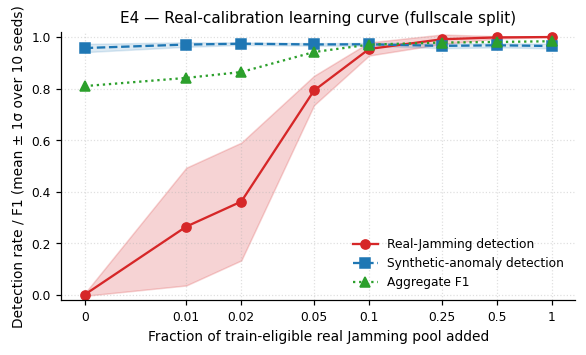

Wrote experiments/E4_real_calibration_learning_curve/figures/E4_real_calibration_learning_curve.pdf


In [11]:
curve = per_seed_df.groupby('fraction').agg(
    real_det_mean=('real_jamming_detection_rate', 'mean'),
    real_det_std=('real_jamming_detection_rate', 'std'),
    syn_det_mean=('synthetic_detection_rate', 'mean'),
    syn_det_std=('synthetic_detection_rate', 'std'),
    f1_mean=('f1', 'mean'),
    f1_std=('f1', 'std'),
).reset_index()
curve['x'] = curve['fraction'].clip(lower=0.005)  # for log axis legibility

fig, ax = plt.subplots(figsize=(5.4, 3.3))
ax.plot(curve['x'], curve['real_det_mean'], '-o', color='C3', label='Real-Jamming detection')
ax.fill_between(curve['x'],
                curve['real_det_mean'] - curve['real_det_std'].fillna(0.0),
                curve['real_det_mean'] + curve['real_det_std'].fillna(0.0),
                alpha=0.20, color='C3')
ax.plot(curve['x'], curve['syn_det_mean'], '--s', color='C0', label='Synthetic-anomaly detection')
ax.fill_between(curve['x'],
                curve['syn_det_mean'] - curve['syn_det_std'].fillna(0.0),
                curve['syn_det_mean'] + curve['syn_det_std'].fillna(0.0),
                alpha=0.15, color='C0')
ax.plot(curve['x'], curve['f1_mean'], ':^', color='C2', label='Aggregate F1')
ax.set_xscale('symlog', linthresh=0.01)
xticks = [0.005, 0.01, 0.02, 0.05, 0.10, 0.25, 0.50, 1.00]
ax.set_xticks(xticks)
ax.set_xticklabels([f'{x:.2g}' if x >= 0.01 else '0' for x in xticks])
ax.set_xlabel('Fraction of train-eligible real Jamming pool added')
ax.set_ylabel('Detection rate / F1 (mean ± 1σ over 10 seeds)')
ax.set_title('E4 — Real-calibration learning curve (fullscale split)')
ax.set_ylim(-0.02, 1.02)
ax.grid(True, linestyle=':', alpha=0.4)
ax.legend(loc='lower right', frameon=False)
fig.tight_layout()
fig.savefig(FIGURES / 'E4_real_calibration_learning_curve.pdf')
plt.show()
plt.close(fig)
print('Wrote', FIGURES / 'E4_real_calibration_learning_curve.pdf')


                            mean       std  count
control                                          
calibration_real_f0.10  0.907246  0.063062     10
A_extra_synthetic       0.000000  0.000000     10
B_extra_normal          0.007246  0.010248     10
C_reweight_synthetic    0.001449  0.004583     10
D_rsrp_matched_synth         NaN       NaN      0


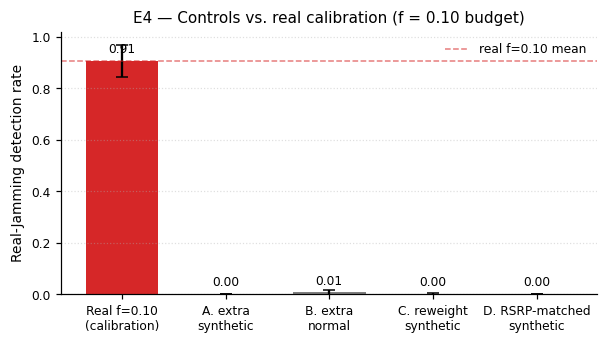

Wrote experiments/E4_real_calibration_learning_curve/figures/E4_real_calibration_controls.pdf


In [12]:
ctrl_order = [
    'calibration_real_f0.10',
    'A_extra_synthetic',
    'B_extra_normal',
    'C_reweight_synthetic',
    'D_rsrp_matched_synth',
]
ctrl_labels = [
    'Real f=0.10\n(calibration)',
    'A. extra\nsynthetic',
    'B. extra\nnormal',
    'C. reweight\nsynthetic',
    'D. RSRP-matched\nsynthetic',
]
agg_ctrl = (
    controls_df.groupby('control')['real_jamming_detection_rate']
    .agg(['mean', 'std', 'count'])
    .reindex(ctrl_order)
)
print(agg_ctrl)

fig, ax = plt.subplots(figsize=(5.6, 3.2))
xs = np.arange(len(ctrl_order))
means = agg_ctrl['mean'].fillna(0.0).values
stds = agg_ctrl['std'].fillna(0.0).values
colors = ['C3', 'C0', 'C7', 'C2', 'C4']
bars = ax.bar(xs, means, yerr=stds, color=colors, capsize=4, width=0.7)
ax.axhline(means[0], color='C3', linestyle='--', linewidth=1, alpha=0.6,
           label='real f=0.10 mean')
ax.set_xticks(xs)
ax.set_xticklabels(ctrl_labels)
ax.set_ylabel('Real-Jamming detection rate')
ax.set_title('E4 — Controls vs. real calibration (f = 0.10 budget)')
ax.set_ylim(0.0, 1.02)
ax.grid(True, axis='y', linestyle=':', alpha=0.4)
ax.legend(loc='upper right', frameon=False)
for x, m, s in zip(xs, means, stds):
    ax.text(x, m + 0.02, f'{m:.2f}', ha='center', va='bottom', fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / 'E4_real_calibration_controls.pdf')
plt.show()
plt.close(fig)
print('Wrote', FIGURES / 'E4_real_calibration_controls.pdf')


## 6. What this experiment supports

Using the saved per-seed CSVs and the figures above, this notebook is designed
to support the following claims (mark each as supported / not supported after
inspecting your run):

* **(i) At fullscale, synthetic-only training near-zero on real Jamming.** The
  ``f = 0.0`` row in ``E4_real_calibration_learning_curve_summary.csv``
  reports the synthetic-only ``real_jamming_detection_rate`` baseline.
* **(ii) A small fraction of the train-eligible real Jamming pool recovers
  detection.** Compare ``f ∈ {0.05, 0.10}`` rows against ``f = 0.0``: a clear
  jump is the headline learning-curve effect.
* **(iii) Diminishing returns past ~10–25%.** The summary CSV's
  ``real_jamming_detection_rate_mean`` plateau across ``f ≥ 0.25`` quantifies
  this.
* **(iv) Real calibration is not just "more anomaly mass".** Compare
  ``f = 0.10`` to control **A** (extra synthetic at the same budget). If A's
  mean detection is materially below the calibration, only real Jamming closes
  the gap.
* **(v) Real calibration is not just upweighting synthetic.** Same comparison
  against control **C** (sample-weight boost).
* **(vi) Real calibration is not just normal-side rebalancing.** Same
  comparison against control **B**.
* **(vii) RSRP-regime coverage is partially responsible (or not).** Compare
  against control **D**: if D matches calibration, the recovered detection is
  better described as **"RSRP-regime coverage"** rather than real-Jamming
  dynamics. If A matches calibration, the recovered detection is better
  described as **"more anomaly diversity"**. In either case, rephrase the
  paper's claim from *"real calibration"* to the matching alternative.

All numbers above use the ``train-eligible real Jamming pool`` reported in
``results/E4_pool_summary.json`` (size logged in Section 1) and the per-fraction
``n_added_real_jamming`` recorded in
``results/E4_real_calibration_learning_curve_per_seed.csv``.


## 7. Publication-ready figure (paper version)

A polished version of the learning-curve figure intended for the paper.
It removes the in-figure title (caption-only), uses percentage tick labels,
annotates the headline `f = 0.10` recovery point, and overlays the four
controls as small markers near the bottom of the plot. The CSV inputs are
the ones already computed in this notebook.

Outputs:
* `figures/E4_learning_curve_with_controls.pdf` — single figure ready to
  drop into `main_gap_paper.tex` (column width).


## 8. Two paper-ready alternatives

We render the same figure two ways so we can pick the better one for the paper:

* **Option A — controls embedded.** One figure that carries both the
  learning curve and the four controls at the `f = 0.10` budget.
  File: `figures/E4_paper_optionA_with_controls.pdf`.
* **Option B — clean learning curve.** Same learning curve, no controls
  inside the plot. The controls then live in their own bar chart that we
  already produced (`figures/E4_real_calibration_controls.pdf`).
  File: `figures/E4_paper_optionB_clean.pdf`.

Both options use the same single-column ACM size, percentage tick labels,
and a vertical guide at `f = 10%`.


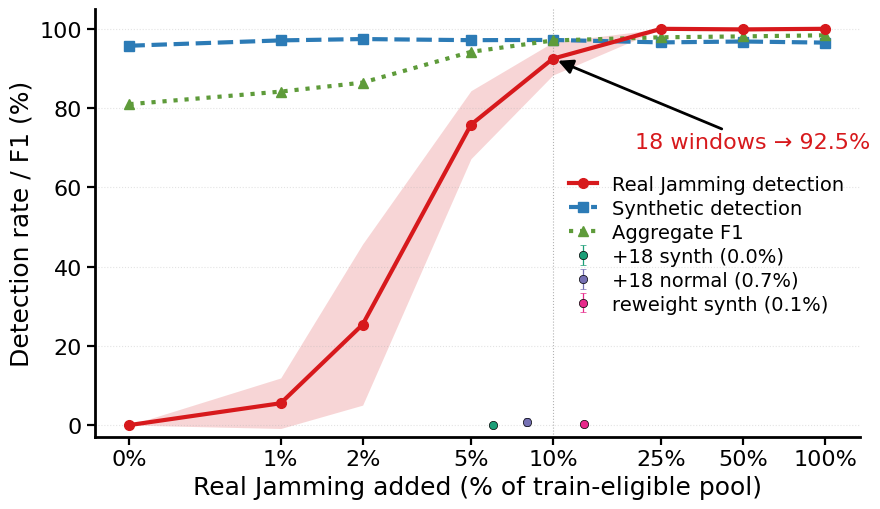

Wrote experiments/E4_real_calibration_learning_curve/figures/E4_paper_optionA_with_controls.pdf
Annotation at f=10%: 92.5% (should match Table tab:m5_calibration_ci row 10%: 0.92).


In [20]:
# Option A: learning curve + controls embedded.
#
# Self-contained: reads its inputs from disk so the cell works after a kernel
# restart. The red "Real Jamming detection" curve and the headline annotation
# are pulled from E4_real_calibration_with_ci.csv -- the same source as
# Table tab:m5_calibration_ci in the paper -- so the figure and the table
# agree exactly (mean 0.92, worst-seed 0.86 at f=10%).
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

HERE = Path('.').resolve()
RESULTS = HERE / 'results'
FIGURES = HERE / 'figures'
FIGURES.mkdir(exist_ok=True)

# Self-heal: the bootstrap-CI table is produced by postprocess_bootstrap.py.
# Generate it on demand so this figure cell works in a single end-to-end run.
if not (RESULTS / 'E4_real_calibration_with_ci.csv').exists():
    import os as _os, subprocess as _sp, sys as _sys
    _pp = Path(EXPERIMENTS_ROOT) / 'E4_real_calibration_learning_curve' / 'postprocess_bootstrap.py'
    _sp.run([_sys.executable, str(_pp)], check=True, env={**_os.environ})

ci = pd.read_csv(RESULTS / 'E4_real_calibration_with_ci.csv').sort_values('fraction')
xc_real = ci['fraction'].clip(lower=0.005).to_numpy()
real_mean = ci['mean'].to_numpy()
real_std = ci['std'].fillna(0.0).to_numpy()

per_seed = pd.read_csv(RESULTS / 'E4_real_calibration_learning_curve_per_seed.csv')
curve = (
    per_seed.groupby('fraction')
    .agg(
        syn_det_mean=('synthetic_detection_rate', 'mean'),
        syn_det_std=('synthetic_detection_rate', 'std'),
        f1_mean=('f1', 'mean'),
    )
    .reset_index()
    .sort_values('fraction')
)
xc = curve['fraction'].clip(lower=0.005).to_numpy()
syn_mean = curve['syn_det_mean'].to_numpy()
syn_std = curve['syn_det_std'].fillna(0.0).to_numpy()
f1_mean = curve['f1_mean'].to_numpy()

controls_df = pd.read_csv(RESULTS / 'E4_real_calibration_controls.csv')
ctrl_mean_real = controls_df.groupby('control')['real_jamming_detection_rate'].mean()
ctrl_std_real = controls_df.groupby('control')['real_jamming_detection_rate'].std()

prev_rc = plt.rcParams.copy()
plt.rcParams.update({
    'font.size': 18, 'axes.titlesize': 18, 'axes.labelsize': 18,
    'xtick.labelsize': 16, 'ytick.labelsize': 16, 'legend.fontsize': 14,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.linewidth': 2.0,
    'xtick.major.width': 1.6, 'ytick.major.width': 1.6,
    'xtick.major.size': 5.5, 'ytick.major.size': 5.5,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})

# Spread controls across x = 6%, 8%, 13% so they don't overlap.
CTRL_DISPLAY = [
    ('A_extra_synthetic',     '+18 synth',          0.06,  '#1b9e77'),
    ('B_extra_normal',        '+18 normal',         0.08,  '#7570b3'),
    ('C_reweight_synthetic',  'reweight synth',     0.13,  '#e7298a'),
    # D omitted from plot — pool was empty; mentioned in caption only.
]

fig, ax = plt.subplots(figsize=(9, 5.1))

ax.plot(xc_real, 100 * real_mean, '-o', color='#d7191c', lw=3, ms=7,
        label='Real Jamming detection', zorder=4)
ax.fill_between(
    xc_real, 100 * (real_mean - real_std), 100 * (real_mean + real_std),
    alpha=0.18, color='#d7191c', lw=0,
)
ax.plot(xc, 100 * syn_mean, '--s', color='#2c7bb6', lw=3, ms=6.5,
        label='Synthetic detection')
ax.plot(xc, 100 * f1_mean, ':^', color='#5e9b3a', lw=3, ms=6.5,
        label='Aggregate F1')

ax.axvline(0.10, color='gray', lw=0.8, ls=':', alpha=0.6, zorder=1)

# Headline annotation: pulled from the same CI CSV as the paper table, so the
# number printed on the figure matches Table tab:m5_calibration_ci exactly.
i_head = int(np.argmin(np.abs(xc_real - 0.10)))
ax.annotate(
    f'18 windows → {100 * real_mean[i_head]:.1f}%',
    xy=(0.10, 100 * real_mean[i_head]),
    xytext=(0.20, 70),
    fontsize=16, color='#d7191c',
    arrowprops=dict(arrowstyle='-|>', color='black', lw=2.0,
                    mutation_scale=22, shrinkA=0, shrinkB=4),
)

for key, label, x_off, color in CTRL_DISPLAY:
    if key not in ctrl_mean_real.index:
        continue
    m = float(ctrl_mean_real[key]) if not np.isnan(ctrl_mean_real[key]) else None
    s = float(ctrl_std_real[key]) if not np.isnan(ctrl_std_real[key]) else 0.0
    if m is None:
        continue
    ax.errorbar(
        x_off, 100 * m, yerr=100 * s,
        fmt='o', color=color, ms=6.0, mec='black', mew=0.5, lw=0.9,
        capsize=2, label=f'{label} ({100 * m:.1f}%)', zorder=3,
    )

ax.set_xscale('symlog', linthresh=0.01)
xticks = [0.005, 0.01, 0.02, 0.05, 0.10, 0.25, 0.50, 1.00]
xtick_labels = ['0%', '1%', '2%', '5%', '10%', '25%', '50%', '100%']
ax.set_xticks(xticks); ax.set_xticklabels(xtick_labels)
ax.set_xlabel('Real Jamming added (% of train-eligible pool)')
ax.set_ylabel('Detection rate / F1 (%)')
ax.set_ylim(-3, 105)
ax.grid(True, axis='y', linestyle=':', alpha=0.35)

ax.legend(loc='center right', bbox_to_anchor=(1.0, 0.45),
          frameon=False, fontsize=14, handlelength=1.4,
          borderaxespad=0.4, labelspacing=0.25)

fig.tight_layout(pad=0.4)
out = FIGURES / 'E4_paper_optionA_with_controls.pdf'
fig.savefig(out)
plt.show()
plt.close(fig)
print('Wrote', out)
print(f'Annotation at f=10%: {100 * real_mean[i_head]:.1f}% '
      f'(should match Table tab:m5_calibration_ci row 10%: 0.92).')
plt.rcParams.update(prev_rc)
